In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import unicodedata
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df_dados = pd.read_excel("Dados para correlação v3 - Xavier.xlsx")

In [3]:
df_dados

,Municipio,Ano,target_por_area,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,...,Wetdays_5,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5
0,Abre_Campo,2012,1.079924,305.53,14.61,7.91,27.16,19.43,2,1,...,9,3,8,1,10.00,29.44,56.81,1,243.97,193.35
1,Abre_Campo,2013,1.079924,178.69,16.92,9.22,27.07,20.67,2,11,...,8,7,17,0,9.30,17.37,49.40,0,407.82,350.25
2,Abre_Campo,2014,0.800000,130.72,16.11,9.80,28.48,20.56,1,6,...,3,3,24,0,1.98,2.92,5.94,0,176.90,147.95
3,Abre_Campo,2015,1.200000,172.37,15.68,8.37,26.65,21.73,0,4,...,8,3,8,2,13.77,38.89,58.17,2,248.73,206.43
4,Abre_Campo,2016,1.200000,151.12,16.25,7.02,28.37,18.94,2,5,...,3,1,13,0,3.69,7.33,32.07,0,133.41,115.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,Vermelho_Novo,2019,1.079913,123.18,17.06,10.35,27.72,20.37,2,8,...,8,4,12,0,5.56,13.13,23.84,0,227.80,173.99
1892,Vermelho_Novo,2020,1.320080,110.88,17.20,9.32,30.05,23.55,5,13,...,7,3,7,0,6.82,18.58,22.41,1,572.00,287.73
1893,Vermelho_Novo,2021,0.960000,98.75,17.44,8.37,28.75,21.81,5,5,...,2,1,15,0,5.50,9.81,9.92,0,373.57,107.24
1894,Vermelho_Novo,2022,0.959821,158.15,17.25,8.11,28.92,21.35,4,3,...,3,3,24,0,1.87,2.79,5.74,0,364.72,82.40


In [4]:
df_dados = df_dados.dropna(axis=1)
df_dados

,Municipio,Ano,target_por_area,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,...,Wetdays_5,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5
0,Abre_Campo,2012,1.079924,305.53,14.61,7.91,27.16,19.43,2,1,...,9,3,8,1,10.00,29.44,56.81,1,243.97,193.35
1,Abre_Campo,2013,1.079924,178.69,16.92,9.22,27.07,20.67,2,11,...,8,7,17,0,9.30,17.37,49.40,0,407.82,350.25
2,Abre_Campo,2014,0.800000,130.72,16.11,9.80,28.48,20.56,1,6,...,3,3,24,0,1.98,2.92,5.94,0,176.90,147.95
3,Abre_Campo,2015,1.200000,172.37,15.68,8.37,26.65,21.73,0,4,...,8,3,8,2,13.77,38.89,58.17,2,248.73,206.43
4,Abre_Campo,2016,1.200000,151.12,16.25,7.02,28.37,18.94,2,5,...,3,1,13,0,3.69,7.33,32.07,0,133.41,115.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,Vermelho_Novo,2019,1.079913,123.18,17.06,10.35,27.72,20.37,2,8,...,8,4,12,0,5.56,13.13,23.84,0,227.80,173.99
1892,Vermelho_Novo,2020,1.320080,110.88,17.20,9.32,30.05,23.55,5,13,...,7,3,7,0,6.82,18.58,22.41,1,572.00,287.73
1893,Vermelho_Novo,2021,0.960000,98.75,17.44,8.37,28.75,21.81,5,5,...,2,1,15,0,5.50,9.81,9.92,0,373.57,107.24
1894,Vermelho_Novo,2022,0.959821,158.15,17.25,8.11,28.92,21.35,4,3,...,3,3,24,0,1.87,2.79,5.74,0,364.72,82.40


In [5]:
correlation_profiles = df_dados.groupby('Municipio')[df_dados.select_dtypes(include=['float64', 'int64']).columns].corr(numeric_only=True)

In [6]:
correlation_profiles

Ano  target_por_area   preco_6     TNx_6  \
Municipio                                                                      
Abre_Campo    Ano              1.000000         0.684666 -0.304823  0.290255   
              target_por_area  0.684666         1.000000  0.125791 -0.089545   
              preco_6         -0.304823         0.125791  1.000000 -0.539291   
              TNx_6            0.290255        -0.089545 -0.539291  1.000000   
              TNn_6           -0.457801        -0.203137 -0.209355 -0.289585   
...                                 ...              ...       ...       ...   
Vermelho_Novo rx1day_5        -0.465747         0.107446  0.327256 -0.520946   
              rx5day_5        -0.526723         0.247816  0.678426 -0.371378   
              r95p_5          -0.471418         0.056785  0.277277 -0.508802   
              pr-wet-qrt_5     0.192869         0.020904 -0.428815 -0.258041   
              pr-dry-qrt_5    -0.375426         0.148974 -0.177617  0.080160   

                                  TNn_6     TXx_6     TXn_6   TX90p_6  \
Municipio                                                               
Abre_Campo    Ano             -0.457801  0.317427  0.205712  0.698244   
              target_por_area -0.203137 -0.038755  0.293319  0.665109   
              preco_6         -0.209355 -0.282721 -0.165972  0.021601   
              TNx_6           -0.289585  0.536798 -0.397226  0.339087   
              TNn_6            1.000000 -0.538845  0.483255 -0.431293   
...                                 ...       ...       ...       ...   
Vermelho_Novo rx1day_5         0.367009 -0.487907  0.483748 -0.460148   
              rx5day_5         0.107296 -0.330628  0.154567 -0.268466   
              r95p_5           0.316067 -0.427881  0.516643 -0.485006   
              pr-wet-qrt_5     0.269532 -0.111832  0.682101  0.000049   
              pr-dry-qrt_5     0.599453  0.047383  0.422465 -0.073687   

                                Tn90p_6    WD30_6  ...  Wetdays_5     CWD_5  \
Municipio                                          ...                        
Abre_Campo    Ano             -0.003600 -0.043671  ...  -0.440151 -0.430952   
              target_por_area -0.023989 -0.315536  ...   0.193969 -0.037720   
              preco_6         -0.633077 -0.099673  ...   0.314607  0.085002   
              TNx_6            0.613451  0.595922  ...  -0.437857 -0.003879   
              TNn_6            0.310520 -0.558211  ...   0.459270  0.612758   
...                                 ...       ...  ...        ...       ...   
Vermelho_Novo rx1day_5         0.012476 -0.159610  ...   0.677796  0.359280   
              rx5day_5        -0.100060 -0.172621  ...   0.695158  0.392417   
              r95p_5           0.150537 -0.102129  ...   0.578518  0.314027   
              pr-wet-qrt_5     0.347849  0.004764  ...   0.100996 -0.007010   
              pr-dry-qrt_5     0.798040  0.136320  ...   0.467129  0.121263   

                                  CDD_5  Wet20mm_5  Prec-Intensity_5  \
Municipio                                                              
Abre_Campo    Ano              0.181278  -0.425919         -0.464761   
              target_por_area -0.477785  -0.110058         -0.036805   
              preco_6         -0.399349   0.392969          0.388630   
              TNx_6            0.454293  -0.559774         -0.327496   
              TNn_6           -0.109289   0.113333          0.138462   
...                                 ...        ...               ...   
Vermelho_Novo rx1day_5        -0.584108   0.904860          0.922747   
              rx5day_5        -0.600740   0.795764          0.735624   
              r95p_5          -0.419834   0.904656          0.790277   
              pr-wet-qrt_5    -0.182528   0.035429          0.362614   
              pr-dry-qrt_5    -0.391806   0.140739          0.521032   

                               rx1day_5  rx5day_5    r95p_5  pr-wet-qrt_5  \
Mun

In [7]:
city_profiles = correlation_profiles.unstack()['target_por_area'].drop(columns='target_por_area')
city_profiles.fillna(0, inplace=True)
city_profiles

,Ano,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,WD30_6,WN22_6,...,Wetdays_5,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5
Municipio,,,,,,,,,,,,,,,,,,,,,
Abre_Campo,0.684666,0.125791,-0.089545,-0.203137,-0.038755,0.293319,0.665109,-0.023989,-0.315536,0.0,...,0.193969,-0.037720,-0.477785,-0.110058,-0.036805,-0.010687,-0.020367,-0.110058,0.076397,-0.104241
Alfenas,-0.032036,-0.217965,-0.090513,0.090761,0.605426,0.451119,0.652955,-0.042675,0.000000,0.0,...,0.017342,0.108424,-0.044113,0.171833,0.020481,0.085376,0.018002,0.171833,0.352718,0.010985
Alpinopolis,-0.484082,0.240012,-0.378213,-0.014112,-0.002282,-0.053949,-0.149048,-0.120950,0.000000,0.0,...,0.506517,0.505614,-0.311384,0.192298,0.149208,0.481816,0.440814,0.192298,0.194411,0.125499
Alterosa,-0.124263,-0.118115,-0.136806,-0.177909,0.258018,0.162477,0.158021,-0.104082,0.000000,0.0,...,0.119279,0.351831,-0.241913,-0.020605,0.056494,0.204220,0.155272,0.008876,0.413929,0.083383
Alto_Caparao,-0.167384,0.019059,-0.155820,0.090119,0.172791,0.115282,-0.006479,-0.032914,0.000000,0.0,...,0.233520,0.150849,-0.280828,-0.201180,-0.011501,-0.008763,-0.047672,-0.201180,0.085870,0.064648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ubaporanga,0.469895,-0.148286,-0.315396,-0.040768,-0.073477,0.541652,0.585305,0.111839,0.271287,0.0,...,0.001435,0.232544,-0.124268,-0.054344,0.105596,0.036223,-0.218007,-0.054344,0.490829,0.241170
Unai,-0.756108,0.296909,0.471866,0.700431,0.045406,-0.196259,0.035113,0.517858,0.190959,0.0,...,-0.071122,-0.043055,0.371141,-0.064241,-0.232153,-0.336101,-0.198488,-0.063882,-0.090636,0.297031
Varginha,0.123240,-0.100561,0.260466,-0.420229,0.266400,0.424853,-0.119540,-0.162005,0.000000,0.0,...,0.098335,0.091423,-0.222692,0.022752,0.012339,0.176563,0.139076,0.006678,0.230579,-0.193599


In [8]:
weather_features = city_profiles.columns

In [9]:
scaler = StandardScaler()
scaled_profiles = scaler.fit_transform(city_profiles)
scaled_profiles

array([[ 1.91436085,  0.54976846, -0.15517663, ..., -0.16451422,
        -0.27337828, -0.39210523],
       [-0.1357817 , -0.77727572, -0.15825441, ...,  0.83634289,
         0.57124517, -0.02948045],
       [-1.42887008,  0.99071058, -1.07348505, ...,  0.90900649,
         0.08735039,  0.33090664],
       ...,
       [ 0.30838819, -0.32404612,  0.95828002, ...,  0.2499597 ,
         0.19790519, -0.67331936],
       [-0.80175867, -0.96938306,  0.81723623, ..., -0.37607449,
        -0.12515794,  0.57306778],
       [ 1.30853002,  0.55508222,  0.1924648 , ...,  0.4278654 ,
        -0.44300163,  0.40478447]], shape=(158, 361))

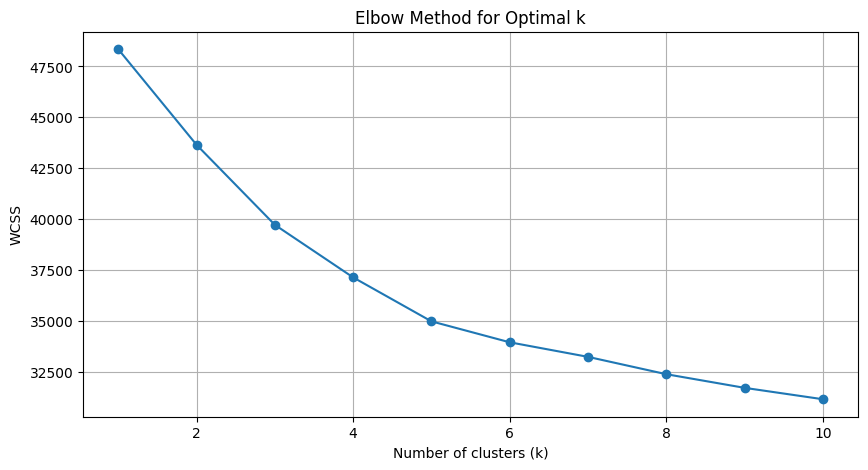

In [10]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_profiles)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [11]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
city_profiles['cluster'] = kmeans.fit_predict(scaled_profiles)

In [12]:
print("\n## Cities and their Assigned Clusters ##")
print(city_profiles[['cluster']].sort_values('cluster'))


## Cities and their Assigned Clusters ##
                     cluster
Municipio                   
Alpinopolis                0
Alto_Caparao               0
Alto_Jequitiba             0
Areado                     0
Bom_Jesus_da_Penha         0
...                      ...
Santa_Rosa_da_Serra        2
Sao_Gotardo                2
Serra_do_Salitre           2
Tiros                      2
Unai                       2

[158 rows x 1 columns]


In [13]:
city_profiles["cluster"].value_counts()

cluster
1    82
0    44
2    32
Name: count, dtype: int64

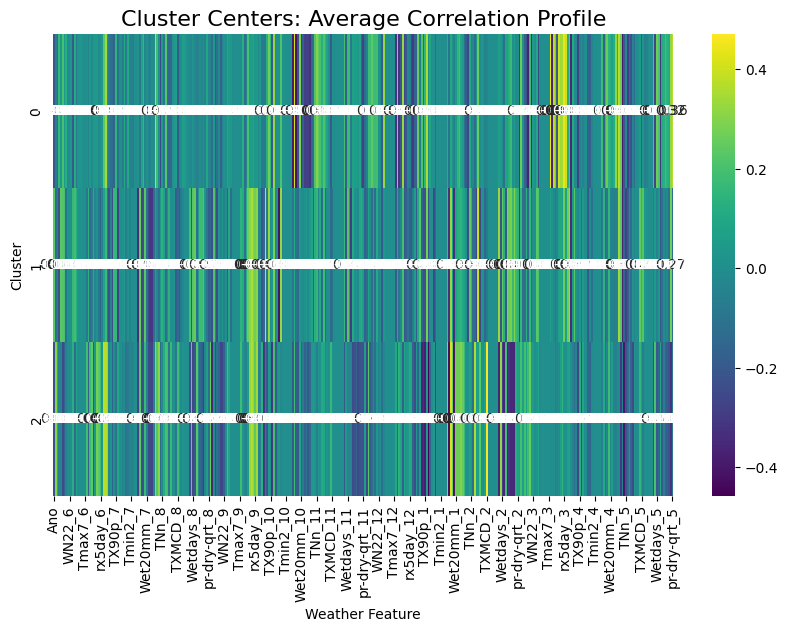

In [14]:
centers_df = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=weather_features)

plt.figure(figsize=(10, 6))
sns.heatmap(centers_df, annot=True, cmap='viridis', fmt='.2f')
plt.title('Cluster Centers: Average Correlation Profile', fontsize=16)
plt.ylabel('Cluster')
plt.xlabel('Weather Feature')
# plt.savefig('cluster_centers_heatmap.png')
plt.show()

In [15]:
fig_heatmap = px.imshow(
    centers_df,
    labels=dict(x="Weather Feature", y="Cluster", color="Correlation"),
    title="Interactive Heatmap of Cluster Centers",
    text_auto=".2f", # Display values on the heatmap
    aspect="auto"
)
fig_heatmap.update_xaxes(tickangle=45)
# Save to an HTML file and show
fig_heatmap.write_html("Heatmap dos clusters em relação as variáveis.html")
print("Saved interactive heatmap to 'interactive_heatmap.html'")
fig_heatmap.show()

Saved interactive heatmap to 'interactive_heatmap.html'


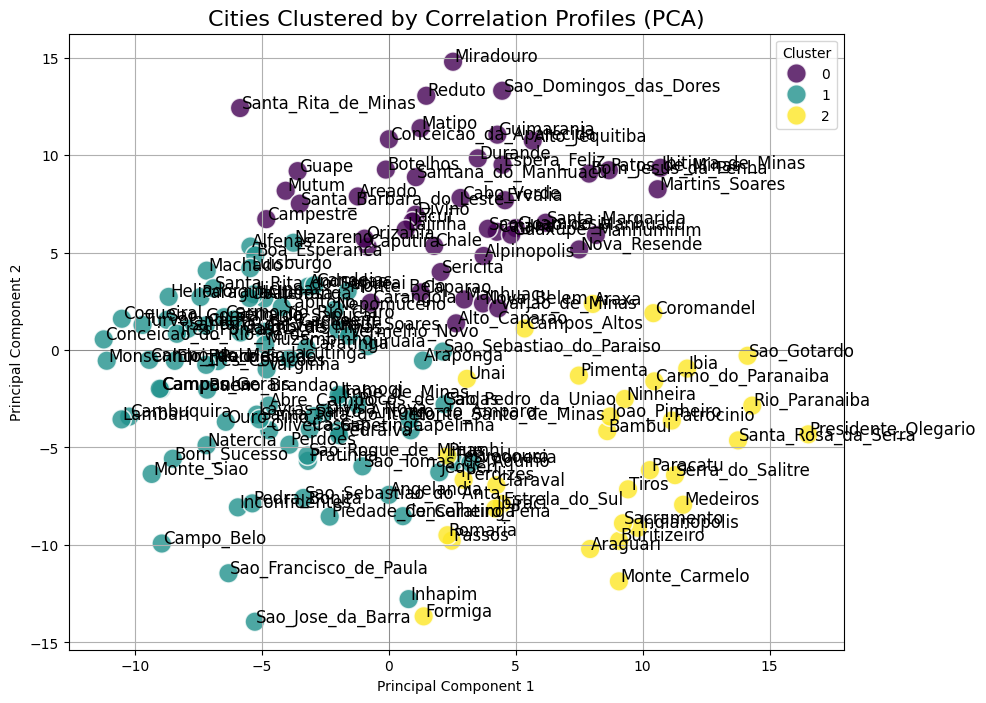

In [16]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_profiles)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=city_profiles.index)
pca_df['cluster'] = city_profiles['cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=200, alpha=0.8)

# Annotate points with city names
for city in pca_df.index:
    plt.text(pca_df.loc[city, 'PC1']+0.05, pca_df.loc[city, 'PC2'], city, fontsize=12)

plt.title('Cities Clustered by Correlation Profiles (PCA)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.legend(title='Cluster')
# plt.savefig('city_clusters_pca.png')
plt.show()

In [17]:
fig_scatter = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='cluster',
    title="Interactive PCA Plot of Clustered Cities",
    hover_name=pca_df.index, # This is the key! Shows city name on hover.
    labels={'cluster': 'Cluster'},
    color_continuous_scale=px.colors.qualitative.Vivid
)
fig_scatter.update_traces(marker=dict(size=10, opacity=0.8))
fig_scatter.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
    legend_title_text='Cluster'
)
# Save to an HTML file and show
fig_scatter.write_html("Visualização dos clusters com base no PCA.html")
print("Saved interactive PCA plot to 'interactive_pca_plot.html'")
fig_scatter.show()

Saved interactive PCA plot to 'interactive_pca_plot.html'


In [18]:
# Calculate the variance for each feature across the cluster centers
feature_variance = centers_df.var(axis=0)
feature_variance

Ano             0.069781
preco_6         0.053178
TNx_6           0.013591
TNn_6           0.040702
TXx_6           0.021403
                  ...   
rx1day_5        0.030818
rx5day_5        0.027036
r95p_5          0.028059
pr-wet-qrt_5    0.123297
pr-dry-qrt_5    0.072965
Length: 361, dtype: float64

In [19]:
# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_variance.index,
    'Importance': feature_variance.values
}).sort_values(by='Importance', ascending=False)
print("## Feature Importance (Ranked by Variance Across Clusters) ##")
print(importance_df)

## Feature Importance (Ranked by Variance Across Clusters) ##
          Feature  Importance
359  pr-wet-qrt_5    0.123297
259     PRCPTOT_2    0.120114
266      rx1day_2    0.113389
268        r95p_2    0.110638
264     Wet20mm_2    0.109860
..            ...         ...
316       Tmin1_4    0.000000
107      Tmax10_9    0.000000
347      Tmax10_5    0.000000
348       Tmax7_5    0.000000
108       Tmax7_9    0.000000

[361 rows x 2 columns]


In [20]:
importance_df.to_excel("Importância das variáveis para criação dos clusters.xlsx", index=False)

In [21]:
# Visualize the feature importances with an interactive bar chart
fig_importance = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    orientation='h', # Horizontal bar chart
    title='Feature Importance for Distinguishing City Clusters'
)
# Ensure the bar chart is sorted from highest to lowest importance
fig_importance.update_layout(yaxis={'categoryorder':'total ascending'})

fig_importance.write_html("Importância das variáveis para criação dos clusters.html")
print("\nSaved interactive feature importance chart to 'feature_importance_chart.html'")
fig_importance.show()


Saved interactive feature importance chart to 'feature_importance_chart.html'


In [22]:
# Method 2: First, calculate the overall average profile across all cities
overall_avg_profile = city_profiles[weather_features].mean()
overall_avg_profile

Ano             0.015432
preco_6        -0.016621
TNx_6          -0.040766
TNn_6          -0.087090
TXx_6           0.125321
                  ...   
rx1day_5       -0.001520
rx5day_5       -0.008453
r95p_5         -0.063723
pr-wet-qrt_5    0.165834
pr-dry-qrt_5    0.020352
Length: 361, dtype: float64

In [23]:
for i in range(k):
    print(f"\n## Profiling Cluster {i} ##")
    cluster_profile = centers_df.iloc[i]
    
    # --- Method 1: Top Features by Strongest Correlation (Magnitude) ---
    top_by_magnitude = cluster_profile.abs().sort_values(ascending=False)
    # Get the original values (with sign) for the top features
    top_features_magnitude = cluster_profile.loc[top_by_magnitude.index].to_frame(name='Correlation')
    
    top_features_magnitude.to_excel(f"Importância das variáveis para o Cluster {i} - Método 1 - Magnitude.xlsx")
    print("\n[Method 1] Top 5 Features by Strongest Correlation (Magnitude):")
    print(top_features_magnitude.head())
    
    # --- Method 2: Top Features by Uniqueness (Lift) ---
    lift = cluster_profile - overall_avg_profile
    top_by_uniqueness = lift.abs().sort_values(ascending=False)
    # Get the original lift values (with sign)
    top_features_uniqueness = lift.loc[top_by_uniqueness.index].to_frame(name='Uniqueness (Lift)')
    
    top_features_uniqueness.to_excel(f"Importância das variáveis para o Cluster {i} - Método 2 - Singularidade.xlsx")
    print("\n[Method 2] Top 5 Most Unique Features (Compared to Average):")
    print(top_features_uniqueness.head())
    print("-" * 60)


## Profiling Cluster 0 ##

[Method 1] Top 5 Features by Strongest Correlation (Magnitude):
            Correlation
rx5day_3       0.440708
PRCPTOT_3      0.439226
Drydays_10     0.416095
Wetdays_10    -0.416095
r95p_3         0.398767

[Method 2] Top 5 Most Unique Features (Compared to Average):
              Uniqueness (Lift)
pr-dry-qrt_5           0.341580
TXMCD_3               -0.311895
TXx_1                  0.302740
TX90p_1                0.302660
PRCPTOT_3              0.286978
------------------------------------------------------------

## Profiling Cluster 1 ##

[Method 1] Top 5 Features by Strongest Correlation (Magnitude):
                  Correlation
TNn_10               0.406890
Tn10p_10            -0.406242
Tn90p_2              0.395030
preco_5             -0.375248
Prec-Intensity_9     0.358363

[Method 2] Top 5 Most Unique Features (Compared to Average):
           Uniqueness (Lift)
TNn_10              0.233402
Ano                 0.218942
PRCPTOT_2           0.214340

In [ ]:
fig, axes = plt.subplots(k, 1, figsize=(10, k * 4.5), sharex=True)
if k == 1: axes = [axes] # Make sure axes is iterable for a single cluster

for i, ax in enumerate(axes):
    cluster_profile = centers_df.iloc[i]
    top_5_features = cluster_profile.abs().nlargest(5).index
    top_5_values = cluster_profile.loc[top_5_features].sort_values()
    
    sns.barplot(x=top_5_values.values, y=top_5_values.index, ax=ax, palette='rocket')
    ax.set_title(f'Top 5 Most Significant Features for Cluster {i}', fontsize=14)
    ax.set_xlabel('Correlation with Coffee Production')
    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
#plt.savefig("cluster_feature_profiles.png")
#print("\nSaved plot of top features for each cluster to 'cluster_feature_profiles.png'")
plt.show()

In [24]:
# Loop through each cluster to create and save its plots
for i in range(k):
    cluster_profile = centers_df.iloc[i]

    # --- Plot for Method 1: Strongest Correlation (Magnitude) ---
    magnitude_df = cluster_profile.to_frame(name='Correlation').reset_index().rename(columns={'index': 'Feature'})
    
    fig1 = px.bar(
        magnitude_df,
        x='Correlation',
        y='Feature',
        orientation='h',
        title=f'Method 1: Strongest Correlations for Cluster {i}',
        color='Correlation', # Color bars by their value
        color_continuous_scale='RdBu_r', # Red-Blue diverging scale
        labels={'Correlation': 'Correlation with Coffee Production'}
    )
    # This automatically sorts the bars from highest to lowest
    fig1.update_layout(yaxis={'categoryorder':'total ascending'})
    fig1.write_html(f"Importância das variáveis para o Cluster {i} - Método 1 - Magnitude.html")
    print(f"Saved plot for Cluster {i}, Method 1 to 'cluster_{i}_method_1_magnitude.html'")
    # fig1.show() # Uncomment to display plots as they are generated

    # --- Plot for Method 2: Uniqueness (Lift) ---
    lift = cluster_profile - overall_avg_profile
    uniqueness_df = lift.to_frame(name='Uniqueness (Lift)').reset_index().rename(columns={'index': 'Feature'})

    fig2 = px.bar(
        uniqueness_df,
        x='Uniqueness (Lift)',
        y='Feature',
        orientation='h',
        title=f'Method 2: Most Unique Features for Cluster {i}',
        color='Uniqueness (Lift)',
        color_continuous_scale='PRGn', # Purple-Green diverging scale
        labels={'Uniqueness (Lift)': 'Difference from Overall Average Correlation'}
    )
    fig2.update_layout(yaxis={'categoryorder':'total ascending'})
    fig2.write_html(f"Importância das variáveis para o Cluster {i} - Método 2 - Singularidade.html")
    print(f"Saved plot for Cluster {i}, Method 2 to 'cluster_{i}_method_2_uniqueness.html'")
    # fig2.show() # Uncomment to display plots as they are generated

Saved plot for Cluster 0, Method 1 to 'cluster_0_method_1_magnitude.html'
Saved plot for Cluster 0, Method 2 to 'cluster_0_method_2_uniqueness.html'
Saved plot for Cluster 1, Method 1 to 'cluster_1_method_1_magnitude.html'
Saved plot for Cluster 1, Method 2 to 'cluster_1_method_2_uniqueness.html'
Saved plot for Cluster 2, Method 1 to 'cluster_2_method_1_magnitude.html'
Saved plot for Cluster 2, Method 2 to 'cluster_2_method_2_uniqueness.html'


In [25]:
df_coord = pd.read_excel("municipios_georeferenciamento.xlsx")
df_coord

,Mesorregião_id,municipio_id,municipio_nome,lat,lon,alt
0,3101,3104502,Arinos - MG,-15.750667,-45.988642,532
1,3101,3108206,Bonfinópolis de Minas - MG,-16.486304,-46.190656,851
2,3101,3108552,Brasilândia de Minas - MG,-16.957007,-45.902536,513
3,3101,3109303,Buritis - MG,-15.453166,-46.604270,611
4,3101,3109451,Cabeceira Grande - MG,-16.076160,-47.123777,842
...,...,...,...,...,...,...
847,3112,3171154,Vermelho Novo - MG,-20.033949,-42.254213,594
848,3112,3171402,Vieiras - MG,-20.912222,-42.281880,561
849,3112,3172004,Visconde do Rio Branco - MG,-21.011695,-42.839972,336
850,3112,3171303,Viçosa - MG,-20.740535,-42.885718,718


In [26]:
df_coord["municipio_nome"] = df_coord["municipio_nome"].apply(lambda x: ''.join([c for c in unicodedata.normalize('NFKD', x.split(" - ")[0].replace("ç", "c")) if not unicodedata.combining(c)]))
df_coord["municipio_nome"] = df_coord["municipio_nome"].apply(lambda x: x.replace(" ", "_"))
df_coord

,Mesorregião_id,municipio_id,municipio_nome,lat,lon,alt
0,3101,3104502,Arinos,-15.750667,-45.988642,532
1,3101,3108206,Bonfinopolis_de_Minas,-16.486304,-46.190656,851
2,3101,3108552,Brasilandia_de_Minas,-16.957007,-45.902536,513
3,3101,3109303,Buritis,-15.453166,-46.604270,611
4,3101,3109451,Cabeceira_Grande,-16.076160,-47.123777,842
...,...,...,...,...,...,...
847,3112,3171154,Vermelho_Novo,-20.033949,-42.254213,594
848,3112,3171402,Vieiras,-20.912222,-42.281880,561
849,3112,3172004,Visconde_do_Rio_Branco,-21.011695,-42.839972,336
850,3112,3171303,Vicosa,-20.740535,-42.885718,718


In [27]:
df_coord = df_coord.rename(columns={'municipio_nome': 'Municipio'})
df_coord

,Mesorregião_id,municipio_id,Municipio,lat,lon,alt
0,3101,3104502,Arinos,-15.750667,-45.988642,532
1,3101,3108206,Bonfinopolis_de_Minas,-16.486304,-46.190656,851
2,3101,3108552,Brasilandia_de_Minas,-16.957007,-45.902536,513
3,3101,3109303,Buritis,-15.453166,-46.604270,611
4,3101,3109451,Cabeceira_Grande,-16.076160,-47.123777,842
...,...,...,...,...,...,...
847,3112,3171154,Vermelho_Novo,-20.033949,-42.254213,594
848,3112,3171402,Vieiras,-20.912222,-42.281880,561
849,3112,3172004,Visconde_do_Rio_Branco,-21.011695,-42.839972,336
850,3112,3171303,Vicosa,-20.740535,-42.885718,718


In [28]:
city_profiles

,Ano,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,WD30_6,WN22_6,...,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5,cluster
Municipio,,,,,,,,,,,,,,,,,,,,,
Abre_Campo,0.684666,0.125791,-0.089545,-0.203137,-0.038755,0.293319,0.665109,-0.023989,-0.315536,0.0,...,-0.037720,-0.477785,-0.110058,-0.036805,-0.010687,-0.020367,-0.110058,0.076397,-0.104241,1
Alfenas,-0.032036,-0.217965,-0.090513,0.090761,0.605426,0.451119,0.652955,-0.042675,0.000000,0.0,...,0.108424,-0.044113,0.171833,0.020481,0.085376,0.018002,0.171833,0.352718,0.010985,1
Alpinopolis,-0.484082,0.240012,-0.378213,-0.014112,-0.002282,-0.053949,-0.149048,-0.120950,0.000000,0.0,...,0.505614,-0.311384,0.192298,0.149208,0.481816,0.440814,0.192298,0.194411,0.125499,0
Alterosa,-0.124263,-0.118115,-0.136806,-0.177909,0.258018,0.162477,0.158021,-0.104082,0.000000,0.0,...,0.351831,-0.241913,-0.020605,0.056494,0.204220,0.155272,0.008876,0.413929,0.083383,1
Alto_Caparao,-0.167384,0.019059,-0.155820,0.090119,0.172791,0.115282,-0.006479,-0.032914,0.000000,0.0,...,0.150849,-0.280828,-0.201180,-0.011501,-0.008763,-0.047672,-0.201180,0.085870,0.064648,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ubaporanga,0.469895,-0.148286,-0.315396,-0.040768,-0.073477,0.541652,0.585305,0.111839,0.271287,0.0,...,0.232544,-0.124268,-0.054344,0.105596,0.036223,-0.218007,-0.054344,0.490829,0.241170,1
Unai,-0.756108,0.296909,0.471866,0.700431,0.045406,-0.196259,0.035113,0.517858,0.190959,0.0,...,-0.043055,0.371141,-0.064241,-0.232153,-0.336101,-0.198488,-0.063882,-0.090636,0.297031,2
Varginha,0.123240,-0.100561,0.260466,-0.420229,0.266400,0.424853,-0.119540,-0.162005,0.000000,0.0,...,0.091423,-0.222692,0.022752,0.012339,0.176563,0.139076,0.006678,0.230579,-0.193599,1


In [29]:
city_profiles.reset_index(inplace=True)
final_df = pd.merge(city_profiles, df_coord, on='Municipio', how='left')
final_df

,Municipio,Ano,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,WD30_6,...,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5,cluster,Mesorregião_id,municipio_id,lat,lon,alt
0,Abre_Campo,0.684666,0.125791,-0.089545,-0.203137,-0.038755,0.293319,0.665109,-0.023989,-0.315536,...,-0.020367,-0.110058,0.076397,-0.104241,1,3112,3100302,-20.273473,-42.442642,897
1,Alfenas,-0.032036,-0.217965,-0.090513,0.090761,0.605426,0.451119,0.652955,-0.042675,0.000000,...,0.018002,0.171833,0.352718,0.010985,1,3110,3101607,-21.388698,-45.966040,830
2,Alpinopolis,-0.484082,0.240012,-0.378213,-0.014112,-0.002282,-0.053949,-0.149048,-0.120950,0.000000,...,0.440814,0.192298,0.194411,0.125499,0,3110,3101904,-20.859726,-46.376291,911
3,Alterosa,-0.124263,-0.118115,-0.136806,-0.177909,0.258018,0.162477,0.158021,-0.104082,0.000000,...,0.155272,0.008876,0.413929,0.083383,1,3110,3102001,-21.225254,-46.153194,847
4,Alto_Caparao,-0.167384,0.019059,-0.155820,0.090119,0.172791,0.115282,-0.006479,-0.032914,0.000000,...,-0.047672,-0.201180,0.085870,0.064648,0,3112,3102050,-20.458770,-41.864698,1057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Ubaporanga,0.469895,-0.148286,-0.315396,-0.040768,-0.073477,0.541652,0.585305,0.111839,0.271287,...,-0.218007,-0.054344,0.490829,0.241170,1,3108,3170057,-19.660697,-42.070377,837
154,Unai,-0.756108,0.296909,0.471866,0.700431,0.045406,-0.196259,0.035113,0.517858,0.190959,...,-0.198488,-0.063882,-0.090636,0.297031,2,3101,3170404,-16.375723,-46.819297,566
155,Varginha,0.123240,-0.100561,0.260466,-0.420229,0.266400,0.424853,-0.119540,-0.162005,0.000000,...,0.139076,0.006678,0.230579,-0.193599,1,3110,3170701,-21.557495,-45.408932,932
156,Varjao_de_Minas,-0.264852,-0.267729,0.216130,0.682364,0.077053,-0.211421,0.048580,0.521766,-0.117037,...,-0.258601,-0.169644,0.124888,0.202447,0,3101,3170750,-18.466418,-45.935044,803


In [30]:
df_dados

,Municipio,Ano,target_por_area,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,...,Wetdays_5,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5
0,Abre_Campo,2012,1.079924,305.53,14.61,7.91,27.16,19.43,2,1,...,9,3,8,1,10.00,29.44,56.81,1,243.97,193.35
1,Abre_Campo,2013,1.079924,178.69,16.92,9.22,27.07,20.67,2,11,...,8,7,17,0,9.30,17.37,49.40,0,407.82,350.25
2,Abre_Campo,2014,0.800000,130.72,16.11,9.80,28.48,20.56,1,6,...,3,3,24,0,1.98,2.92,5.94,0,176.90,147.95
3,Abre_Campo,2015,1.200000,172.37,15.68,8.37,26.65,21.73,0,4,...,8,3,8,2,13.77,38.89,58.17,2,248.73,206.43
4,Abre_Campo,2016,1.200000,151.12,16.25,7.02,28.37,18.94,2,5,...,3,1,13,0,3.69,7.33,32.07,0,133.41,115.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,Vermelho_Novo,2019,1.079913,123.18,17.06,10.35,27.72,20.37,2,8,...,8,4,12,0,5.56,13.13,23.84,0,227.80,173.99
1892,Vermelho_Novo,2020,1.320080,110.88,17.20,9.32,30.05,23.55,5,13,...,7,3,7,0,6.82,18.58,22.41,1,572.00,287.73
1893,Vermelho_Novo,2021,0.960000,98.75,17.44,8.37,28.75,21.81,5,5,...,2,1,15,0,5.50,9.81,9.92,0,373.57,107.24
1894,Vermelho_Novo,2022,0.959821,158.15,17.25,8.11,28.92,21.35,4,3,...,3,3,24,0,1.87,2.79,5.74,0,364.72,82.40


In [31]:
df_dataset_modelo = pd.merge(df_dados, city_profiles[['Municipio', 'cluster']], on='Municipio', how='left')
df_dataset_modelo

,Municipio,Ano,target_por_area,preco_6,TNx_6,TNn_6,TXx_6,TXn_6,TX90p_6,Tn90p_6,...,CWD_5,CDD_5,Wet20mm_5,Prec-Intensity_5,rx1day_5,rx5day_5,r95p_5,pr-wet-qrt_5,pr-dry-qrt_5,cluster
0,Abre_Campo,2012,1.079924,305.53,14.61,7.91,27.16,19.43,2,1,...,3,8,1,10.00,29.44,56.81,1,243.97,193.35,1
1,Abre_Campo,2013,1.079924,178.69,16.92,9.22,27.07,20.67,2,11,...,7,17,0,9.30,17.37,49.40,0,407.82,350.25,1
2,Abre_Campo,2014,0.800000,130.72,16.11,9.80,28.48,20.56,1,6,...,3,24,0,1.98,2.92,5.94,0,176.90,147.95,1
3,Abre_Campo,2015,1.200000,172.37,15.68,8.37,26.65,21.73,0,4,...,3,8,2,13.77,38.89,58.17,2,248.73,206.43,1
4,Abre_Campo,2016,1.200000,151.12,16.25,7.02,28.37,18.94,2,5,...,1,13,0,3.69,7.33,32.07,0,133.41,115.90,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,Vermelho_Novo,2019,1.079913,123.18,17.06,10.35,27.72,20.37,2,8,...,4,12,0,5.56,13.13,23.84,0,227.80,173.99,1
1892,Vermelho_Novo,2020,1.320080,110.88,17.20,9.32,30.05,23.55,5,13,...,3,7,0,6.82,18.58,22.41,1,572.00,287.73,1
1893,Vermelho_Novo,2021,0.960000,98.75,17.44,8.37,28.75,21.81,5,5,...,1,15,0,5.50,9.81,9.92,0,373.57,107.24,1
1894,Vermelho_Novo,2022,0.959821,158.15,17.25,8.11,28.92,21.35,4,3,...,3,24,0,1.87,2.79,5.74,0,364.72,82.40,1


In [32]:
df_dataset_modelo.to_csv("Dataset com features climáticas - Base Xavier.csv", index=False, sep=";")

In [ ]:
city_profiles.to_excel("Dataset final de correlação dos municípios com target.xlsx", index=False)

In [33]:
# 4. Create the interactive map using the new 'final_df'
fig = px.scatter_map(
    final_df,
    lat="lat",
    lon="lon",
    color="cluster",
    hover_name="Municipio", # Use the 'city' column for hover text
    hover_data={"cluster": True, "lat": False, "lon": False},
    title="Geographical Distribution of City Clusters in Minas Gerais Region",
    color_continuous_scale=px.colors.qualitative.Vivid,
    zoom=6,
    center={"lat": -19.9245, "lon": -43.9352},
    map_style="open-street-map"
    # mapbox_style="open-street-map"
)
# map_style list: open-street-map, carto-positron, carto-darkmatterm
fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    legend_title_text='Cluster'
)

fig.write_html("Visualização dos clusters por localização geográfica.html")
print("\nSaved interactive map to 'minas_gerais_cluster_map.html'")
fig.show()


Saved interactive map to 'minas_gerais_cluster_map.html'
